In [101]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [102]:
df = pd.read_csv("/Users/ansh/Desktop/SCAS_Streamlit/ data/placedata.csv")
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [103]:
df.drop('StudentID', axis=1, inplace=True)
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [104]:
from sklearn.preprocessing import LabelEncoder

le_ExtracurricularActivities = LabelEncoder()
le_PlacementTraining = LabelEncoder()
le_PlacementStatus = LabelEncoder()
df['ExtracurricularActivities'] = le_ExtracurricularActivities.fit_transform(df['ExtracurricularActivities'])
df['PlacementTraining'] = le_PlacementTraining.fit_transform(df['PlacementTraining'])
df['PlacementStatus'] =le_PlacementStatus.fit_transform(df['PlacementStatus'])

In [105]:
df.shape

(10000, 11)

In [106]:
df.columns

Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities',
       'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus'],
      dtype='str')

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       10000 non-null  float64
 1   Internships                10000 non-null  int64  
 2   Projects                   10000 non-null  int64  
 3   Workshops/Certifications   10000 non-null  int64  
 4   AptitudeTestScore          10000 non-null  int64  
 5   SoftSkillsRating           10000 non-null  float64
 6   ExtracurricularActivities  10000 non-null  int64  
 7   PlacementTraining          10000 non-null  int64  
 8   SSC_Marks                  10000 non-null  int64  
 9   HSC_Marks                  10000 non-null  int64  
 10  PlacementStatus            10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [108]:
df.describe()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,0.585400,0.731800,69.159400,74.501500,0.419700
std,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,0.492677,0.443044,10.430459,8.919527,0.493534
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,0.000000,0.000000,55.000000,57.000000,0.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,0.000000,0.000000,59.000000,67.000000,0.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,1.000000,1.000000,70.000000,73.000000,0.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,1.000000,1.000000,78.000000,83.000000,1.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,1.000000,1.000000,90.000000,88.000000,1.000000


In [109]:
df.isnull().sum()

CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [110]:
df.duplicated().sum()

72

In [111]:
df.drop_duplicates(ignore_index=True,inplace=True)

In [112]:
df['PlacementStatus'].value_counts()

PlacementStatus
0    5801
1    4127
Name: count, dtype: int64

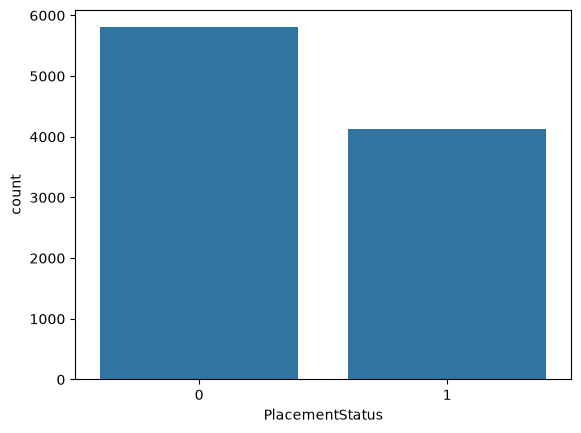

In [113]:
sns.countplot(x='PlacementStatus', data=df)
plt.show()

In [114]:
for col in df.columns:
    print(col)

CGPA
Internships
Projects
Workshops/Certifications
AptitudeTestScore
SoftSkillsRating
ExtracurricularActivities
PlacementTraining
SSC_Marks
HSC_Marks
PlacementStatus


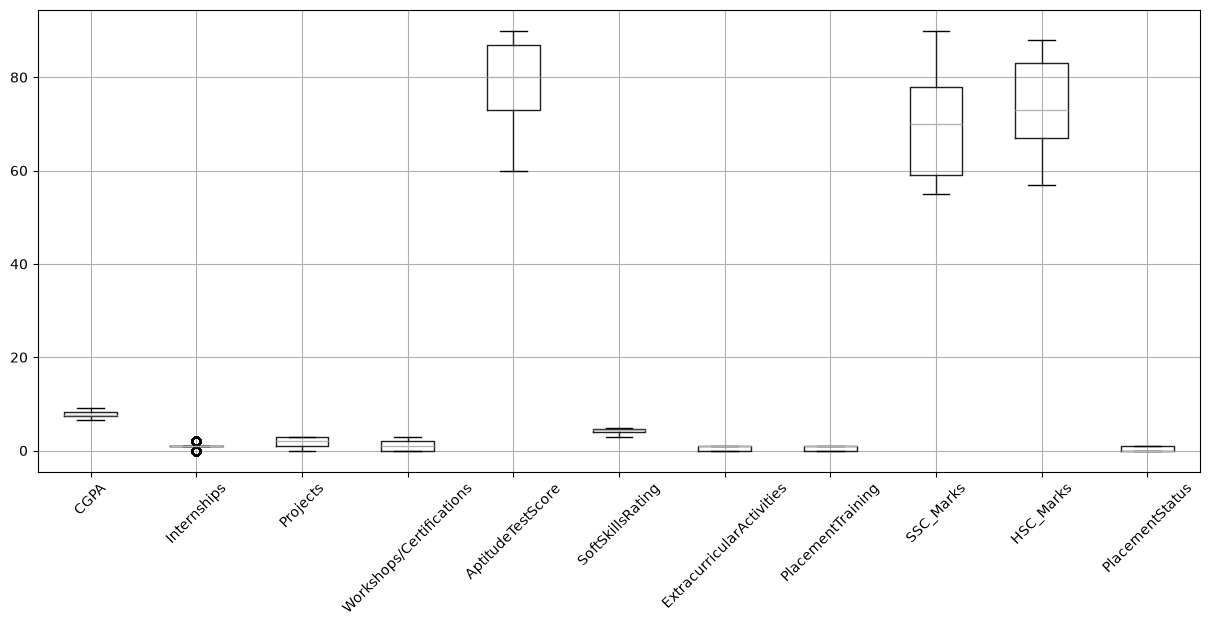

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [116]:
df.describe()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
count,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000,9928.000000
mean,7.693946,1.042808,2.019944,1.006849,79.376209,4.320679,0.582595,0.729855,69.093372,74.425766,0.415693
std,0.639961,0.663699,0.867118,0.903612,8.140884,0.411211,0.493156,0.444057,10.428709,8.901786,0.492866
min,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,0.000000,0.000000,55.000000,57.000000,0.000000
25%,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,0.000000,0.000000,59.000000,67.000000,0.000000
50%,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,1.000000,1.000000,70.000000,73.000000,0.000000
75%,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,1.000000,1.000000,78.000000,83.000000,1.000000
max,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,1.000000,1.000000,90.000000,88.000000,1.000000


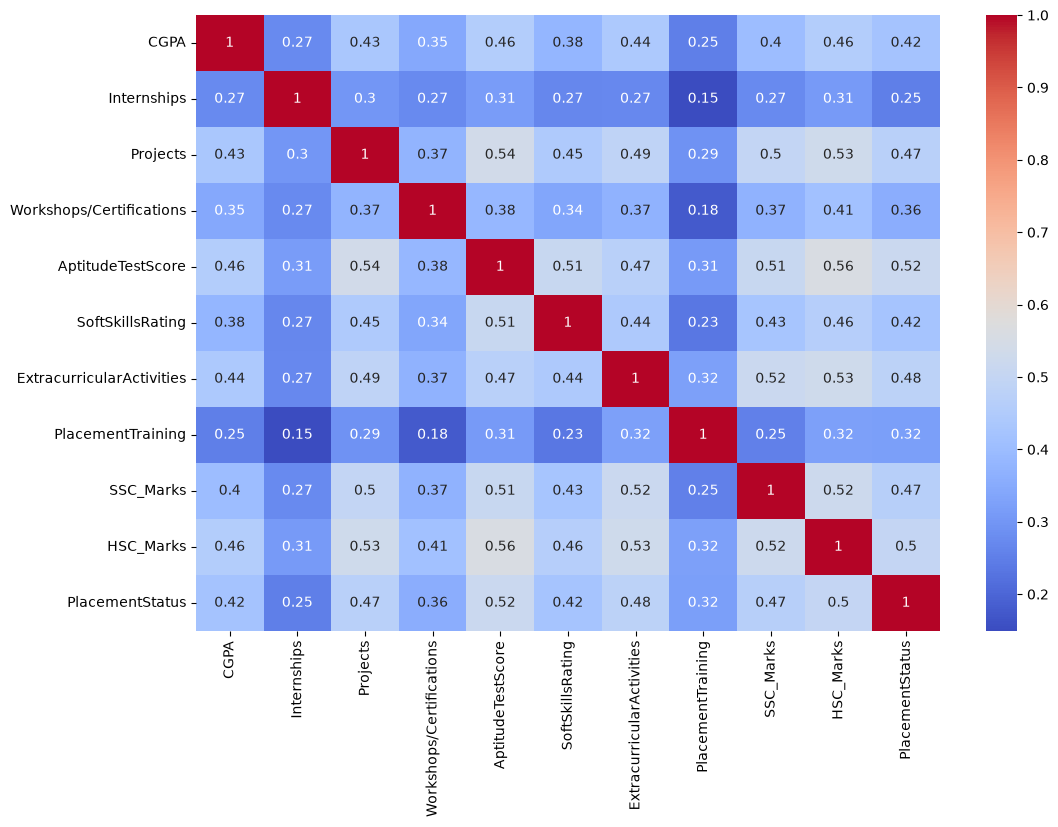

In [117]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.savefig("heatmap.png",
            bbox_inches="tight",
            dpi=300)
plt.show()

In [118]:
X = df.drop('PlacementStatus', axis=1)
y = df['PlacementStatus']

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [121]:
ann = Sequential()

ann.add(Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)))

ann.add(Dense(32, activation="relu"))

ann.add(Dense(16, activation="relu"))

ann.add(Dense(1, activation="sigmoid"))

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann.summary()

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
history = ann.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5640 - loss: 0.8341 - val_accuracy: 0.5727 - val_loss: 0.7182
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6477 - loss: 0.6314 - val_accuracy: 0.7294 - val_loss: 0.5746
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6890 - loss: 0.6006 - val_accuracy: 0.7275 - val_loss: 0.5530
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7308 - loss: 0.5481 - val_accuracy: 0.7445 - val_loss: 0.5300
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7488 - loss: 0.5310 - val_accuracy: 0.6853 - val_loss: 0.6064
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7234 - loss: 0.5644 - val_accuracy: 0.7514 - val_loss: 0.5196
Epoch 7/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7312 - loss: 0.5551 - val_accuracy: 0.7489 - val_loss: 0.5321
Epoch 8/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7499 - loss: 0.5283 - val_acc

In [123]:
loss, ann_acc = ann.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7800 - loss: 0.4609
Test Accuracy : 0.8031218529707955


In [124]:
y_prob = ann.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1188
           1       0.71      0.75      0.73       798

    accuracy                           0.78      1986
   macro avg       0.77      0.78      0.77      1986
weighted avg       0.78      0.78      0.78      1986



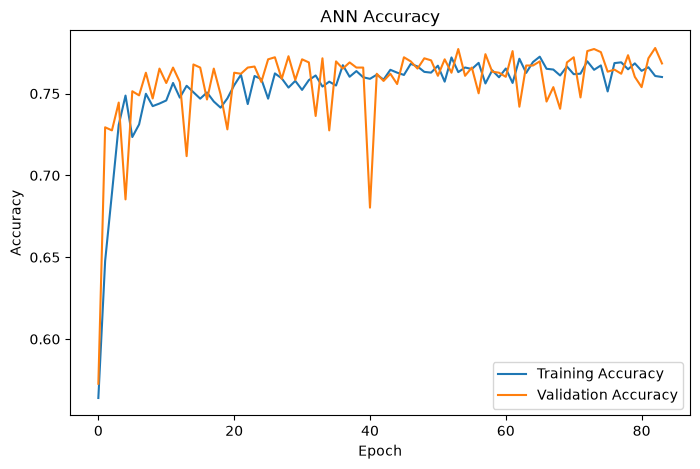

In [125]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("ann_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

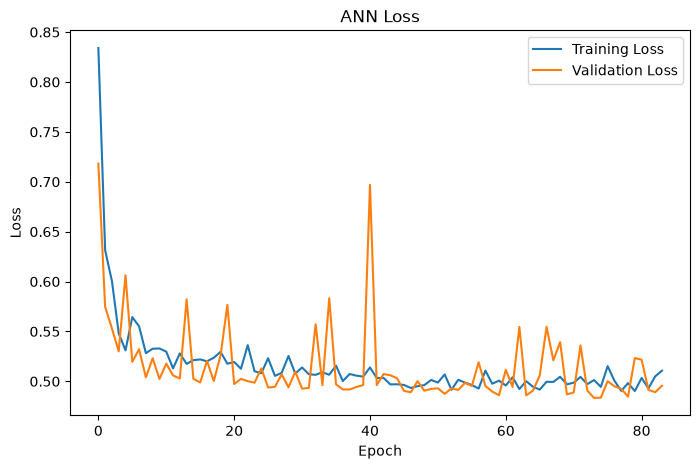

In [126]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("ann_loss.png", dpi=300, bbox_inches="tight")

plt.show()

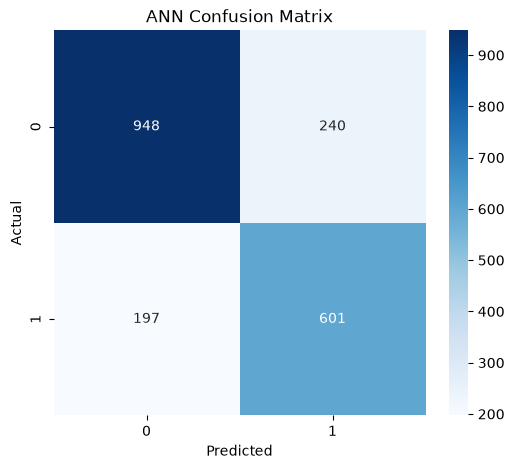

In [127]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("ann_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [128]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7084592145015106


In [129]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy :", lr_acc)
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy : 0.8031218529707955
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1188
           1       0.74      0.79      0.76       798

    accuracy                           0.80      1986
   macro avg       0.80      0.80      0.80      1986
weighted avg       0.81      0.80      0.80      1986



In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7950654582074521


In [131]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.7895266868076536


In [132]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.798590130916415


In [133]:
results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'ANN'
    ],
    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc,
        knn_acc,
        svm_acc,
        ann_acc
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Algorithm,Accuracy
0,Logistic Regression,0.803122
4,SVM,0.798590
2,Random Forest,0.795065
3,KNN,0.789527
5,ANN,0.779960
1,Decision Tree,0.708459


In [134]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.7933739991408186


In [135]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

NameError: name 'y_pred_lr' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("confusion_matrix.png",
            bbox_inches="tight",
            dpi=300)
plt.show()

In [ ]:


importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(lr.coef_[0])
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

In [ ]:


importance.plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.ylabel("Absolute Coefficient")

plt.savefig("Feature Graph.png",
            bbox_inches="tight",
            dpi=300)
plt.show()

In [ ]:
#project 2 Student Segmentation (Clustering)

In [ ]:
X_cluster = df[
    [
        'CGPA',
        'AptitudeTestScore',
        'SoftSkillsRating',
        'Projects',
        'SSC_Marks',
        'HSC_Marks'
    ]
]

In [ ]:
X_cluster.shape

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_cluster_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.savefig("Elbow Method.png",
            bbox_inches="tight",
            dpi=300)
plt.show()

In [ ]:


kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_cluster_scaled)

df['Cluster'] = clusters

In [ ]:
df['Cluster'].value_counts()

In [ ]:
cluster_analysis = df.groupby('Cluster').mean()

cluster_analysis

In [ ]:
cluster_names = {
    0: 'Average Student',
    1: 'At-Risk Student',
    2: 'High Potential Student'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_names)

In [ ]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    pca_components[:,0],
    pca_components[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Student Segmentation using K-Means')
plt.savefig("Student Segmentation using K-Means.png",
            bbox_inches="tight",
            dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_cluster_scaled,
    df['Cluster']
)

print("Silhouette Score:", score)

In [ ]:
#Career Improvement Advisor using Machine Learning

In [ ]:
def generate_recommendations(
    cgpa,
    internships,
    projects,
    workshops,
    aptitude,
    softskills,
    extracurricular,
    placement_training,
    ssc,
    hsc
):

    recommendations = []

    # Highest priority
    if aptitude < 75:
        recommendations.append("🔥 Improve Aptitude Score to 75+ through regular practice.")

    if placement_training == 0:
        recommendations.append("🔥 Join Placement Training Programs.")

    if extracurricular == 0:
        recommendations.append("🔥 Participate in Extracurricular Activities.")

    # Medium priority
    if cgpa < 7:
        recommendations.append("📚 Improve CGPA above 7.0.")

    if projects < 2:
        recommendations.append("💻 Complete at least 2 academic or personal projects.")

    if internships < 1:
        recommendations.append("🏢 Gain internship experience.")

    if softskills < 4:
        recommendations.append("🗣️ Improve communication and presentation skills.")

    # Low priority
    if workshops < 1:
        recommendations.append("🎓 Attend workshops and certification programs.")

    if len(recommendations) == 0:
        recommendations.append(
            "✅ Excellent profile. Focus on interview preparation and premium placement drives."
        )

    return recommendations[:5]

In [ ]:
recommendations = generate_recommendations(
    cgpa=6.5,
    internships=0,
    projects=1,
    workshops=0,
    aptitude=60,
    softskills=3.5,
    extracurricular=0,
    placement_training=0,
    ssc=65,
    hsc=68
)

for rec in recommendations:
    print(rec)